C:\Users\iamro\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


Generating training data...


Generating dataset: 100%|██████████| 3000/3000 [00:01<00:00, 1699.36it/s]



Training Logistic Regression...

LOGREG Results:
QoS Accuracy: 76.83%
Interval Accuracy: 95.17%
Critical AUC: 0.9952
Critical F1: 0.9727
Avg Pseudo-Reward: 3.93

Training Random Forest...

RANDOMFOREST Results:
QoS Accuracy: 88.33%
Interval Accuracy: 95.17%
Critical AUC: 0.9931
Critical F1: 0.9707
Avg Pseudo-Reward: 4.30

Training MLP...

MLP Results:
QoS Accuracy: 88.33%
Interval Accuracy: 95.17%
Critical AUC: 0.9950
Critical F1: 0.9707
Avg Pseudo-Reward: 4.43


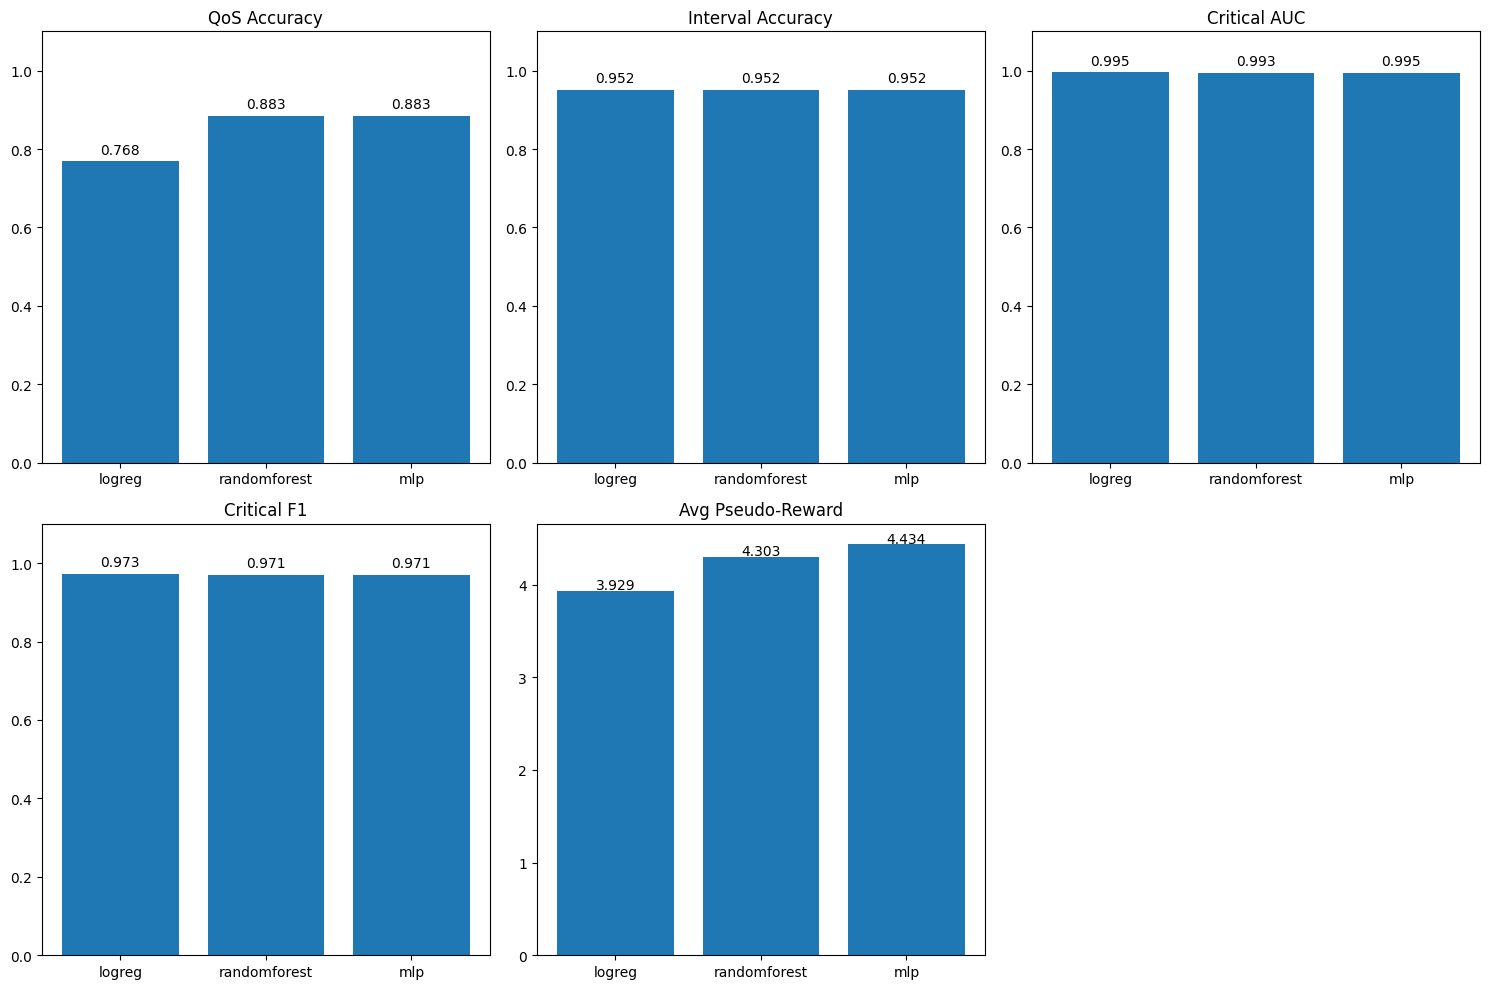


--- Policy Analysis using model: logreg ---
State=(0, 2, 0, 0)
  Model best action: QoS=0, Interval=60s, Critical=0
  Ideal QoS: 0, Ideal Interval: 5s
  Critical match: ✓
  Top 3 model actions by probability:
    1. QoS=0, Interval=60s, Critical=0  (P=0.809)
    2. QoS=0, Interval=30s, Critical=0  (P=0.139)
    3. QoS=1, Interval=60s, Critical=0  (P=0.044)
State=(2, 0, 2, 2)
  Model best action: QoS=2, Interval=5s, Critical=1
  Ideal QoS: 2, Ideal Interval: 5s
  Critical match: ✓
  Top 3 model actions by probability:
    1. QoS=2, Interval=5s, Critical=1  (P=0.923)
    2. QoS=2, Interval=30s, Critical=1  (P=0.074)
    3. QoS=1, Interval=5s, Critical=1  (P=0.002)
State=(1, 1, 1, 1)
  Model best action: QoS=1, Interval=30s, Critical=1
  Ideal QoS: 1, Ideal Interval: 5s
  Critical match: ✓
  Top 3 model actions by probability:
    1. QoS=1, Interval=30s, Critical=1  (P=0.391)
    2. QoS=0, Interval=30s, Critical=1  (P=0.223)
    3. QoS=1, Interval=30s, Critical=0  (P=0.148)

--- Policy A

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm
from torch.distributions import Categorical



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class RealisticEnvSimulator:
    def __init__(self):
        self.battery = 1.0
        self.window_size = 20
        self.delay_window = []
        self.loss_window = []
        self.delta_ema = None
        self.delta_alpha = 0.1
        self.delta_std = 1.0

    def update_ema(self, x):
        if self.delta_ema is None:
            self.delta_ema = x
        else:
            self.delta_ema = self.delta_alpha * x + \
                (1 - self.delta_alpha) * self.delta_ema
        return self.delta_ema

    def compute_delta(self, x):
        ema = self.update_ema(x)
        delta = abs(x - ema) / (self.delta_std + 1e-8)
        return delta

    def compute_loss_rate(self):
        if len(self.loss_window) < self.window_size:
            return 0.0
        return 1.0 - np.mean(self.loss_window[-self.window_size:])

    def compute_avg_delay(self):
        if len(self.delay_window) == 0:
            return 0
        return np.mean(self.delay_window[-self.window_size:])

    def discretize_state(self, delta, battery, loss, delay):
        if delta < 1:
            delta_lvl = 0   
        elif delta < 3:
            delta_lvl = 1  
        else:
            delta_lvl = 2  

        if battery < 0.3:
            battery_lvl = 0 
        elif battery < 0.7:
            battery_lvl = 1 
        else:
            battery_lvl = 2 

        
        if loss < 0.1:
            loss_lvl = 0    
        elif loss < 0.3:
            loss_lvl = 1  
        else:
            loss_lvl = 2  

        
        if delay < 100:
            delay_lvl = 0    
        elif delay < 500:
            delay_lvl = 1  
        else:
            delay_lvl = 2  

        return delta_lvl, battery_lvl, loss_lvl, delay_lvl

    def simulate_environment(self, state, action):
        delta_lvl, battery_lvl, loss_lvl, delay_lvl = state
        qos, interval, critical = action

        sensor_value = np.random.uniform(10, 30)  
        delta = self.compute_delta(sensor_value)

        qos_energy = 0.05 * qos
        interval_energy = 2.0 / interval
        energy_cost = qos_energy + interval_energy
        self.battery = max(0.0, self.battery - energy_cost * 0.05)

        base_delay = np.random.normal(100 + 50 * (2 - qos), 20)
        delay = np.clip(base_delay + 1000 / interval, 0, 800)
        self.delay_window.append(delay)


        loss_chance = 0.1 * (2 - qos) + 0.01 * delay / \
            100 
        is_delivered = np.random.rand() > loss_chance
        self.loss_window.append(int(is_delivered))

        packet_status = 'dropped'
        if is_delivered:
            packet_status = 'on_time' if delay < 300 else 'late'
        latency = delay if is_delivered else 1000


        next_delta_lvl = 0 if delta < 1 else (1 if delta < 3 else 2)
        next_battery_lvl = 0 if self.battery < 0.3 else (
            1 if self.battery < 0.7 else 2)
        loss_rate = self.compute_loss_rate()
        next_loss_lvl = 0 if loss_rate < 0.1 else (1 if loss_rate < 0.3 else 2)
        avg_delay = self.compute_avg_delay()
        next_delay_lvl = 0 if avg_delay < 100 else (
            1 if avg_delay < 500 else 2)

        new_state = (next_delta_lvl, next_battery_lvl,
                     next_loss_lvl, next_delay_lvl)


        total_risk = delta_lvl + (2 - battery_lvl) + loss_lvl + delay_lvl + qos
        normalized_risk = total_risk / 5
        true_crit = 1 if normalized_risk >= 1 else 0

        return new_state, packet_status, true_crit, energy_cost, latency


class SupervisedLearningComparison:
    def __init__(self):
        self.env = RealisticEnvSimulator()
        self.reward_weights = {
            'timeliness': 1.5,
            'criticality': 2.0,
            'qos_match': 2.0,
            'interval_match': 2.0,
            'tau_cost': 1.0,
            'qos_cost': 1.0,
            'kappa': 2.0,
            'latency_penalty': 0.5
        }
        self.qos_levels = [0, 1, 2]
        self.intervals = [5, 30, 60]
        self.critical_flags = [0, 1]
        self.logreg_qos = None
        self.logreg_interval = None
        self.logreg_critical = None
        self.rf_qos = None
        self.rf_interval = None
        self.rf_critical = None
        self.mlp_qos_model = None
        self.mlp_interval_model = None
        self.mlp_critical_model = None


        self.metrics = {
            'logreg': defaultdict(list),
            'randomforest': defaultdict(list),
            'mlp': defaultdict(list)
        }

    def get_state_tensor(self, state):
        return torch.FloatTensor(state).unsqueeze(0).to(device)
    
    def policy(self, state_tensor,which_model='mlp'):

        if which_model in ("logreg", "rf"):
            x = state_tensor.cpu().numpy().reshape(1, -1)
            if which_model == "logreg":
                qos_p = self.logreg_qos.predict_proba(x)[0]
                int_p = self.logreg_interval.predict_proba(x)[0]
                crit_p = self.logreg_critical.predict_proba(x)[0]
            else:
                qos_p = self.rf_qos.predict_proba(x)[0]
                int_p = self.rf_interval.predict_proba(x)[0]
                crit_p = self.rf_critical.predict_proba(x)[0]
            qos_probs = torch.tensor(qos_p,    device=device).unsqueeze(0)
            interval_probs = torch.tensor(int_p,    device=device).unsqueeze(0)
            crit_probs = torch.tensor(crit_p,   device=device).unsqueeze(0)

        elif which_model == "ensemble":
            x = state_tensor.cpu().numpy().reshape(1, -1)
            qos_l_r = self.logreg_qos.predict_proba(x)[0]
            qos_rf = self.rf_qos.predict_proba(x)[0]
            qos_ml = torch.softmax(self.mlp_qos_model(
                state_tensor), dim=1).cpu().numpy()[0]
            qos_avg = 0.333*(qos_l_r + qos_rf + qos_ml)
            
            int_l_r = self.logreg_interval.predict_proba(x)[0]
            int_rf = self.rf_interval.predict_proba(x)[0]
            int_ml = torch.softmax(self.mlp_interval_model(
                state_tensor), dim=1).cpu().numpy()[0]
            int_avg = 0.333*(int_l_r + int_rf + int_ml)
            crit_l_r = self.logreg_critical.predict_proba(x)[0]
            crit_rf = self.rf_critical.predict_proba(x)[0]
            crit_ml = torch.softmax(self.mlp_critical_model(
                state_tensor), dim=1).cpu().numpy()[0]
            crit_avg = 0.333*(crit_l_r + crit_rf + crit_ml)

            qos_probs = torch.tensor(qos_avg,    device=device).unsqueeze(0)
            interval_probs = torch.tensor(
                int_avg,    device=device).unsqueeze(0)
            crit_probs = torch.tensor(crit_avg,   device=device).unsqueeze(0)

        else:
            # MLPs
            qos_probs = torch.softmax(
                self.mlp_qos_model(state_tensor),    dim=1)
            interval_probs = torch.softmax(
                self.mlp_interval_model(state_tensor), dim=1)
            crit_probs = torch.softmax(
                self.mlp_critical_model(state_tensor), dim=1)

        
        joint = torch.einsum('bi,bj,bk->bijk', qos_probs,
                             interval_probs, crit_probs)
        action_probs = joint.reshape(1, -1)
        state_value = torch.tensor([[0.0]], device=device)
        return action_probs, state_value
    def select_action(self, state):
        state_tensor = self.get_state_tensor(state)
        with torch.no_grad():
            action_probs, state_value = self.policy(state_tensor)

        dist = Categorical(action_probs)
        action_idx = dist.sample()
        log_prob = dist.log_prob(action_idx)

        return action_idx.item(), log_prob.item(), state_value.item()

    def state_to_index(self, delta_lvl, battery_lvl, loss_lvl, delay_lvl):
        return (delta_lvl * 27 + battery_lvl * 9 +
                loss_lvl * 3 + delay_lvl)
    def index_to_action(self, action_idx):
        qos = action_idx // 6
        remainder = action_idx % 6
        interval_idx = remainder // 2
        critical = remainder % 2
        return qos, self.intervals[interval_idx], critical

    def generate_dataset(self, num_episodes=1000):
        
        states = []
        optimal_actions = []
        rewards = []

        for _ in tqdm(range(num_episodes), desc="Generating dataset"):
            self.env = RealisticEnvSimulator()
            delta = np.random.uniform(0, 4)
            battery = np.random.uniform(0.1, 1.0)
            loss = np.random.uniform(0, 0.5)
            delay = np.random.uniform(0, 600)

        
            state = self.env.discretize_state(delta, battery, loss, delay)
            states.append(state)

        
            best_reward = -float('inf')
            best_action = None

            for qos in self.qos_levels:
                for interval in self.intervals:
                    for critical in self.critical_flags:
                        action = (qos, interval, critical)
                        _, packet_status, true_crit, _, latency = self.env.simulate_environment(
                            state, action)
                        reward = self.calculate_reward(
                            state, action, packet_status, true_crit, latency)

                        if reward > best_reward:
                            best_reward = reward
                            best_action = action

            optimal_actions.append(best_action)
            rewards.append(best_reward)

        
        X = np.array(states)
        y_qos = np.array([a[0] for a in optimal_actions])
        y_interval = np.array([self.intervals.index(a[1])
                              for a in optimal_actions])
        y_critical = np.array([a[2] for a in optimal_actions])
        rewards = np.array(rewards)

        return X, y_qos, y_interval, y_critical, rewards

    def calculate_reward(self, state, action, packet_status, true_crit, latency):
        
        delta_lvl, battery_lvl, loss_lvl, delay_lvl = state
        qos, interval, critical = action

        if packet_status == 'on_time':
            R_rel = 1.0
        elif packet_status == 'late':
            R_rel = 0.5
        else:  
            R_rel = -1.0

        R_crit = 1.0 if critical == true_crit else -1.0


        ideal_qos = 2 if (loss_lvl >= 2 or delay_lvl >= 2) else \
            1 if (loss_lvl >= 1 or delay_lvl >= 1) else 0
        R_qos = 1.0 if qos == ideal_qos else -1.0


        ideal_interval = 5 if delta_lvl == 2 else \
            30 if delta_lvl == 1 else 60
        R_int = 1.0 if interval == ideal_interval else -1.0


        battery = 0.3 + battery_lvl * 0.4
        f_Bt = 1 + self.reward_weights['kappa'] * (1 - battery)
        C_qos = qos / 2
        C_int = (60 - interval) / (60 - 5)
        penalty = f_Bt * (self.reward_weights['tau_cost'] * C_int +
                          self.reward_weights['qos_cost'] * C_qos)

        total_reward = (self.reward_weights['timeliness'] * R_rel +
                        self.reward_weights['criticality'] * R_crit +
                        self.reward_weights['qos_match'] * R_qos +
                        self.reward_weights['interval_match'] * R_int -
                        penalty)

        
        total_reward -= self.reward_weights['latency_penalty'] * \
            min(1, latency/800)

        return np.clip(total_reward*2, -5.0, 5.0)

    def _get_ideal_qos(self, state):
        delta_lvl, battery_lvl, loss_lvl, delay_lvl = state

        if loss_lvl >= 2 or delay_lvl >= 2 or delta_lvl >= 2:
            return 2
        elif (loss_lvl >= 1 or delay_lvl >= 1) and battery_lvl >= 1:
            return 1
        else:
            return 0

    def _get_ideal_interval(self, state):
        delta_lvl, battery_lvl, _, _ = state

        if delta_lvl == 2 or battery_lvl >= 1:
            return 5
        elif delta_lvl == 1:
            return 30
        else:
            return 60

    def train_models(self, X, y_qos, y_interval, y_critical, rewards, test_size=0.2):
        
        split_idx = int(len(X) * (1 - test_size))
        X_train, X_test = X[:split_idx], X[split_idx:]
        y_qos_train, y_qos_test = y_qos[:split_idx], y_qos[split_idx:]
        y_interval_train, y_interval_test = y_interval[:split_idx], y_interval[split_idx:]
        y_critical_train, y_critical_test = y_critical[:split_idx], y_critical[split_idx:]
        rewards_train, rewards_test = rewards[:split_idx], rewards[split_idx:]

        # 1. Logistic Regression
        print("\nTraining Logistic Regression...")
        
        logreg_qos = LogisticRegression(
            max_iter=1000).fit(X_train, y_qos_train)
        logreg_interval = LogisticRegression(
            max_iter=1000).fit(X_train, y_interval_train)
        logreg_critical = LogisticRegression(
            max_iter=1000).fit(X_train, y_critical_train)
        self.logreg_qos = LogisticRegression(
            max_iter=1000).fit(X_train, y_qos_train)
        self.logreg_interval = LogisticRegression(
            max_iter=1000).fit(X_train, y_interval_train)
        self.logreg_critical = LogisticRegression(
            max_iter=1000).fit(X_train, y_critical_train)
        self.evaluate_model("logreg", logreg_qos, logreg_interval, logreg_critical,
                            X_test, y_qos_test, y_interval_test, y_critical_test, rewards_test)

        # 2. Random Forest
        print("\nTraining Random Forest...")
        rf_qos = RandomForestClassifier(
            n_estimators=100).fit(X_train, y_qos_train)
        rf_interval = RandomForestClassifier(
            n_estimators=100).fit(X_train, y_interval_train)
        rf_critical = RandomForestClassifier(
            n_estimators=100).fit(X_train, y_critical_train)
        self.rf_qos = RandomForestClassifier(n_estimators=100).fit(X_train, y_qos_train)
        self.rf_interval = RandomForestClassifier(n_estimators=100).fit(X_train, y_interval_train)
        self.rf_critical = RandomForestClassifier(n_estimators=100).fit(X_train, y_critical_train)
        self.evaluate_model("randomforest", rf_qos, rf_interval, rf_critical,
                            X_test, y_qos_test, y_interval_test, y_critical_test, rewards_test)

        # 3. MLP (PyTorch implementation)
        print("\nTraining MLP...")
        mlp_qos = self.train_mlp(X_train, y_qos_train, output_dim=3)
        mlp_interval = self.train_mlp(X_train, y_interval_train, output_dim=3)
        mlp_critical = self.train_mlp(X_train, y_critical_train, output_dim=2)

        self.evaluate_model("mlp", mlp_qos, mlp_interval, mlp_critical,
                            X_test, y_qos_test, y_interval_test, y_critical_test, rewards_test)
        self.mlp_qos_model = mlp_qos
        self.mlp_interval_model = mlp_interval
        self.mlp_critical_model = mlp_critical
    def train_mlp(self, X, y, output_dim=3, epochs=50, batch_size=32):
        X_tensor = torch.FloatTensor(X)
        y_tensor = torch.LongTensor(y)

        dataset = TensorDataset(X_tensor, y_tensor)
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

        model = nn.Sequential(
            nn.Linear(4, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )

        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

        for epoch in range(epochs):
            for inputs, labels in loader:
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

        return model

    def evaluate_model(self, model_name, qos_model, interval_model, critical_model,
                       X_test, y_qos_test, y_interval_test, y_critical_test, rewards_test):
        
        if model_name == "mlp":
            with torch.no_grad():
                X_test_tensor = torch.FloatTensor(X_test)
                qos_pred = qos_model(X_test_tensor).argmax(dim=1).numpy()
                interval_pred = interval_model(
                    X_test_tensor).argmax(dim=1).numpy()
                critical_pred = critical_model(
                    X_test_tensor).argmax(dim=1).numpy()
        else:
            qos_pred = qos_model.predict(X_test)
            interval_pred = interval_model.predict(X_test)
            critical_pred = critical_model.predict(X_test)

        
        qos_acc = accuracy_score(y_qos_test, qos_pred)
        interval_acc = accuracy_score(y_interval_test, interval_pred)

        
        if model_name == "mlp":
            with torch.no_grad():
                critical_probs = torch.softmax(
                    critical_model(X_test_tensor), dim=1).numpy()[:, 1]
        else:
            critical_probs = critical_model.predict_proba(X_test)[:, 1]

        critical_auc = roc_auc_score(y_critical_test, critical_probs)
        critical_f1 = f1_score(y_critical_test, critical_pred)

        
        pseudo_rewards = []
        for i in range(len(X_test)):
            state = tuple(X_test[i])
            action = (
                qos_pred[i],
                self.intervals[interval_pred[i]],
                critical_pred[i]
            )
            
            _, packet_status, true_crit, _, latency = self.env.simulate_environment(
                state, action)
            reward = self.calculate_reward(
                state, action, packet_status, true_crit, latency)
            pseudo_rewards.append(reward)

        avg_pseudo_reward = np.mean(pseudo_rewards)

        
        self.metrics[model_name]['qos_acc'].append(qos_acc)
        self.metrics[model_name]['interval_acc'].append(interval_acc)
        self.metrics[model_name]['critical_auc'].append(critical_auc)
        self.metrics[model_name]['critical_f1'].append(critical_f1)
        self.metrics[model_name]['pseudo_reward'].append(avg_pseudo_reward)

        
        print(f"\n{model_name.upper()} Results:")
        print(f"QoS Accuracy: {qos_acc:.2%}")
        print(f"Interval Accuracy: {interval_acc:.2%}")
        print(f"Critical AUC: {critical_auc:.4f}")
        print(f"Critical F1: {critical_f1:.4f}")
        print(f"Avg Pseudo-Reward: {avg_pseudo_reward:.2f}")

    def plot_results(self):
        models = ['logreg', 'randomforest', 'mlp']
        metrics = ['qos_acc', 'interval_acc',
                   'critical_auc', 'critical_f1', 'pseudo_reward']
        metric_names = ['QoS Accuracy', 'Interval Accuracy',
                        'Critical AUC', 'Critical F1', 'Avg Pseudo-Reward']

        plt.figure(figsize=(15, 10))

        for i, metric in enumerate(metrics):
            plt.subplot(2, 3, i+1)
            values = [np.mean(self.metrics[model][metric]) for model in models]
            plt.bar(models, values)
            plt.title(metric_names[i])
            plt.ylim(0, 1.1 if metric != 'pseudo_reward' else None)
            for j, v in enumerate(values):
                plt.text(j, v + 0.02, f"{v:.3f}", ha='center')

        plt.tight_layout()
        plt.show()

    def analyze_policy(self, which_model="mlp"):
        print(f"\n--- Policy Analysis using model: {which_model} ---")

        test_states = [
            (0, 2, 0, 0),  # Small Δ, High battery, Low loss/delay
            (2, 0, 2, 2),  # Large Δ, Low battery, High loss/delay
            (1, 1, 1, 1)   # Medium everything
        ]

        for state in test_states:
            # Convert to tensor and get joint action distribution from the specified model
            state_tensor = self.get_state_tensor(state)
            action_probs, _ = self.policy(state_tensor, which_model)
            action_probs = action_probs.squeeze().cpu()

            best_idx = int(torch.argmax(action_probs))
            qos, interval, critical = self.index_to_action(best_idx)

            ideal_qos = self._get_ideal_qos(state)
            ideal_interval = self._get_ideal_interval(state)
            true_crit = 1 if (sum(state) + qos) / 5 >= 1 else 0

            print(f"State={state}")
            print(
                f"  Model best action: QoS={qos}, Interval={interval}s, Critical={critical}")
            print(
                f"  Ideal QoS: {ideal_qos}, Ideal Interval: {ideal_interval}s")
            print(f"  Critical match: {'✓' if critical == true_crit else '✗'}")

            top3 = torch.topk(action_probs, k=3).indices.numpy()
            print("  Top 3 model actions by probability:")
            for rank, act_idx in enumerate(top3, start=1):
                q, tau, c = self.index_to_action(int(act_idx))
                prob = action_probs[int(act_idx)].item()
                print(
                    f"    {rank}. QoS={q}, Interval={tau}s, Critical={c}  (P={prob:.3f})")


if __name__ == "__main__":
    comparator = SupervisedLearningComparison()

    print("Generating training data...")
    X, y_qos, y_interval, y_critical, rewards = comparator.generate_dataset(
        num_episodes=3000)

    comparator.train_models(X, y_qos, y_interval, y_critical, rewards)

    comparator.plot_results()
    comparator.analyze_policy(which_model="logreg")
    comparator.analyze_policy(which_model="rf")
    comparator.analyze_policy(which_model="mlp")